In [49]:
import pandas as pd
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp


In [50]:
def load(d):
    with open(f"../output/{d}/leiden_results/result_communities_HGNC_selected.pkl", "rb") as f:
        communities_HGNC = pickle.load(f)
    # with open(f"../output/{d}/leiden_results/result_graph.pkl", "rb") as f:
    #     graph = pickle.load(f)    
    with open(f"../output/{d}/gene_to_index_distinct.json", "r") as file:
        gene_to_index_distinct = json.load(file)
        
    return communities_HGNC,gene_to_index_distinct

In [51]:
disease = "schizophrenia"  # Example disease name
DISEASE = "SCHIZOPHRENIA"

In [52]:
with open("../../Data/disease_to_snomed_id.json", "r") as file:
    disease_to_snomed_id = json.load(file)
LIST_OF_OTHER_DISEASES = list(disease_to_snomed_id.keys())
LIST_OF_OTHER_DISEASES.remove(DISEASE)
LIST_OF_OTHER_DISEASES.append("NONE")

In [53]:
communities_HGNC_selected, gene_to_index_distinct = load(DISEASE)

# Open target comparison

In [ ]:
open_targets = pd.read_csv("../../Data/openTargets.tsv", sep="\t")
print(len(open_targets))

In [ ]:
open_targets

,diseaseId,targetId,score,evidenceCount,diseaseCommonName,geneCommonName
0,DOID_0050890,ENSG00000001084,0.031799,4,synucleinopathy,GCLC
1,DOID_0050890,ENSG00000004142,0.002217,1,synucleinopathy,POLDIP2
2,DOID_0050890,ENSG00000004478,0.002217,1,synucleinopathy,FKBP4
3,DOID_0050890,ENSG00000004948,0.002957,1,synucleinopathy,CALCR
4,DOID_0050890,ENSG00000005381,0.002217,1,synucleinopathy,MPO
...,...,...,...,...,...,...
2841998,Orphanet_99946,ENSG00000172409,0.039183,1,Charcot-Marie-Tooth disease type 2A1,CLP1
2841999,Orphanet_99946,ENSG00000179902,0.063280,4,Charcot-Marie-Tooth disease type 2A1,CFAP276
2842000,Orphanet_99946,ENSG00000196876,0.041851,1,Charcot-Marie-Tooth disease type 2A1,SCN8A
2842001,Orphanet_99947,ENSG00000101986,0.033780,1,Charcot-Marie-Tooth disease type 2A2,ABCD1


In [ ]:
disease_related_genes_df = open_targets[open_targets["diseaseCommonName"] == disease]
disease_related_genes_df = disease_related_genes_df.sort_values(by="score", ascending=False)
print("Number of related genes:",len(disease_related_genes_df))

Number of related genes: 6486


In [ ]:
disease_related_genes_df

,diseaseId,targetId,score,evidenceCount,diseaseCommonName,geneCommonName
1665173,MONDO_0005090,ENSG00000149295,0.704699,2470,schizophrenia,DRD2
1662023,MONDO_0005090,ENSG00000040608,0.670540,30,schizophrenia,RTN4R
1665258,MONDO_0005090,ENSG00000151577,0.657935,586,schizophrenia,DRD3
1666623,MONDO_0005090,ENSG00000177000,0.644561,192,schizophrenia,MTHFR
1662867,MONDO_0005090,ENSG00000102468,0.625009,1692,schizophrenia,HTR2A
...,...,...,...,...,...,...
1662312,MONDO_0005090,ENSG00000075073,0.001130,1,schizophrenia,TACR2
1667130,MONDO_0005090,ENSG00000188818,0.001113,1,schizophrenia,ZDHHC11
1664389,MONDO_0005090,ENSG00000134531,0.001111,1,schizophrenia,EMP1
1667962,MONDO_0005090,ENSG00000267322,0.001089,1,schizophrenia,SNHG22


In [ ]:
for i in range(len(communities_HGNC_selected)):
    print(i)
    print(disease_related_genes_df[(disease_related_genes_df["geneCommonName"].isin(communities_HGNC_selected[i])) & 
                                   (disease_related_genes_df["score"] > 0.2)]
          [["geneCommonName","evidenceCount","score"]])
    print("=" * 50)

NameError: name 'communities_HGNC_selected' is not defined

In [ ]:
top_comm_len = 30
top_score_len = 20

In [ ]:
opentarget_comm_score_matrix = np.zeros([top_comm_len,top_score_len])
for i in range(top_comm_len):
    score_list = list(disease_related_genes_df[disease_related_genes_df["geneCommonName"].isin(communities_HGNC[i])]["score"])[:20]
    score_list_padded = score_list + [0] * max(0, top_score_len - len(score_list))
    opentarget_comm_score_matrix[i] = score_list_padded

In [ ]:
def plot_heatmap(M, row_labels=None, col_labels=None,
                 cmap="viridis", vmin=None, vmax=None, save_path = None):
    """
    Plot a heatmap for a 2D matrix, with optional row/column labels.
    """
    M = np.asarray(M)

    plt.figure()
    im = plt.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    plt.colorbar(im)

    # Optional labels
    if row_labels is not None:
        plt.yticks(range(len(row_labels)), row_labels)
    else:
        plt.yticks([])

    if col_labels is not None:
        plt.xticks(range(len(col_labels)), col_labels, rotation=90)
    else:
        plt.xticks([])

    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()

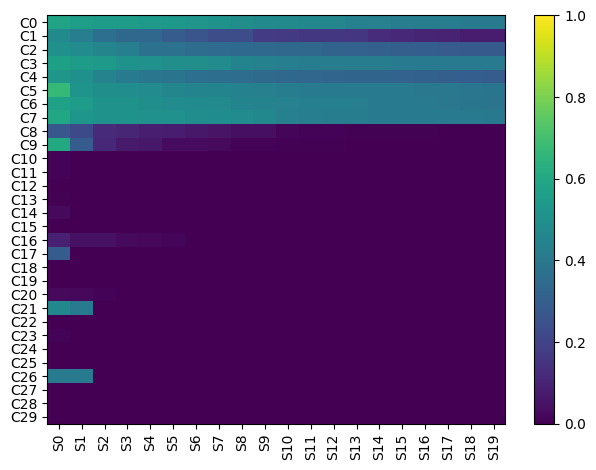

In [ ]:
plot_heatmap(
    opentarget_comm_score_matrix, 
    row_labels=[f"C{i}" for i in range(opentarget_comm_score_matrix.shape[0])],
    col_labels=[f"S{j}" for j in range(opentarget_comm_score_matrix.shape[1])],
    vmin=0, vmax=1
)